**Explanation**

## User-Agnostic Item Ranking Algorithm

This notebook implements a user-agnostic item ranking algorithm that aims to find a robust average rating for each item, filtering out potential outliers. The goal is to provide a reliable item ranking that is not biased by individual user variations.

### **How it Works**

1.  **Load Dataset:** The notebook begins by loading a tab-separated dataset containing user-item ratings, including a "normalized\_rating" column.
2.  **Iterate Through Items:** The algorithm then iterates through each unique item in the dataset.
3.  **Iterative Mean Filtering:** For each item, it performs an iterative process:
    * Calculate the mean and standard deviation of the item's ratings.
    * Filter out ratings that deviate significantly (more than one standard deviation) from the mean.
    * Repeat until no more ratings are filtered out (convergence).
4.  **Compute Final Ranking:** The final ranking for each item is determined by the mean of the remaining (filtered) ratings.
5.  **Visualize Results:** The notebook then creates a histogram to visualize the distribution of the calculated item rankings.

### **This notebook will:**

* Load a tab-separated dataset containing user-item ratings.
* Implement a user-agnostic item ranking algorithm.
* Generate a histogram showing the distribution of the resulting item rankings.
* Filter outliers from item ratings to get a more robust mean.

**1.  Imports**

In [11]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
from collections import defaultdict

**2.    Load Dataset**

In [12]:
file_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/goodreads_reviews_spoiler.json"  # Replace with your dataset path

# Load dataset
with open(file_path, 'r') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# Get unique users and items
users = df["user_id"].unique()
items = df["book_id"].unique()

# Normalize the 'overall' column to range [0, 1]
min_rating = 0
max_rating = 5

print(df["rating"].min(), df["rating"].max())  # Check min and max ratings in the dataset
df["normalizedOverall"] = (df["rating"] - min_rating + 1) / (max_rating - min_rating + 1)

num_unique_items = df["user_id"].nunique()
num_unique_users = df["book_id"].nunique()
num_normalized_ratings = df["normalizedOverall"].notnull().sum()

print(f"Number of unique items (asin): {num_unique_items}")
print(f"Number of unique users (reviewerID): {num_unique_users}")
print(f"Total number of normalized ratings: {num_normalized_ratings}")

overall_min = df['normalizedOverall'].min()
overall_max = df['normalizedOverall'].max()

print("Overall minimum normalized rating:", overall_min)
print("Overall maximum normalized rating:", overall_max)

0 5
Number of unique items (asin): 18892
Number of unique users (reviewerID): 25475
Total number of normalized ratings: 1378033
Overall minimum normalized rating: 0.16666666666666666
Overall maximum normalized rating: 1.0


**3. User-Agnostic Bipartite ranking computation**

In [13]:
def user_agnostic_ranking(dataset, tol=1e-6):
    # Output dictionaries
    item_rankings = {}
    filtered_ratings_byItem = defaultdict(list)

    # Group by item and include user_id and normalized_rating
    grouped = dataset.groupby("book_id")[["user_id", "normalizedOverall"]]

    for item, group in grouped:
        # Convert to list of tuples: [(user_id, rating), ...]
        user_ratings = list(zip(group["user_id"], group["normalizedOverall"]))
        converged = False

        while not converged:
            # Extract just the ratings for calculation
            ratings_only = [r for _, r in user_ratings]
            μ_i = np.mean(ratings_only)
            σ_i = np.std(ratings_only) if len(ratings_only) > 1 else 0

            # Filter and track removed
            new_user_ratings = []
            removed = []

            for uid, r in user_ratings:
                if (r - μ_i) ** 2 <= σ_i:
                    new_user_ratings.append((uid, r))
                else:
                    removed.append((uid, r))

            # Track filtered ratings
            filtered_ratings_byItem[item].extend(removed)

            # Convergence check
            converged = (len(new_user_ratings) == len(user_ratings))
            user_ratings = new_user_ratings

        # Store final ranking
        final_ratings = [r for _, r in user_ratings]
        item_rankings[item] = np.mean(final_ratings) if final_ratings else np.nan

    return item_rankings, filtered_ratings_byItem


**4.    Compute item rankings**

In [14]:
# Compute rankings using the bipartite ranking algorithm
item_rankings, filtered_ratings_byItem = user_agnostic_ranking(df)

print("item_rankings: ", item_rankings)

# Display top-ranked items
sorted_rankings = sorted(item_rankings.items(), key=lambda x: x[1], reverse=True)
sorted_rankings[:10]

item_rankings:  {'1': 0.9412121212121214, '10000191': 0.7954545454545454, '10002296': 0.8425925925925927, '10006': 0.8541666666666667, '10016013': 0.9201388888888888, '10021341': 0.824074074074074, '10021420': 0.5802469135802469, '10024227': 0.8690476190476192, '10024937': 0.8133333333333332, '10025007': 0.7633333333333333, '10025305': 0.9178891605541971, '10029663': 0.7884615384615384, '10031259': 0.8189655172413793, '10032672': 0.8158813263525304, '10035073': 0.9305555555555557, '100365': 0.7888888888888889, '10043376': 0.6, '10047683': 0.696969696969697, '100485': 0.826086956521739, '10048874': 0.7869198312236286, '10050463': 0.9375, '10051392': 0.8636363636363638, '10051706': 0.7454545454545454, '10053149': 0.7797619047619049, '10054335': 0.8193384223918576, '10059498': 0.7904761904761906, '10063343': 0.7205882352941176, '10065': 0.8947368421052632, '10072160': 0.6635802469135803, '10073': 0.7136150234741784, '10075553': 0.7105263157894738, '10079321': 0.7905982905982907, '10082454

[('11497913', 1.0),
 ('15721276', 1.0),
 ('16046121', 1.0),
 ('16148398', 1.0),
 ('22037471', 1.0),
 ('22844208', 1.0),
 ('23691093', 1.0),
 ('23941148', 1.0),
 ('25473485', 1.0),
 ('27228341', 1.0)]

**5. Visualizing the Distribution of Item Rankings**

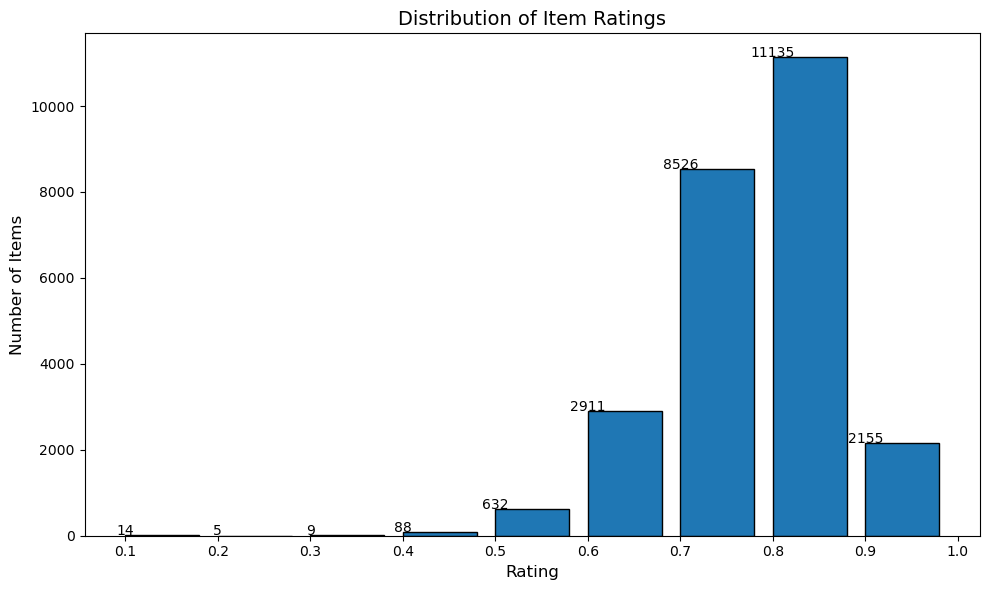

In [15]:
# Extract the ratings from the rankings
ratings = list(item_rankings.values())

# Define bins for the ratings (from 0.1 to 1.0 with steps of 0.1)
bins = np.arange(0.1, 1.1, 0.1)

# Count how many items fall into each rating bin
hist, bin_edges = np.histogram(ratings, bins=bins)

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], hist, width=0.08, align='edge', edgecolor='black')

# Adding numbers on top of bars
for i in range(len(hist)):
    plt.text(bin_edges[i], hist[i] + 1, str(hist[i]), ha='center', fontsize=10)

# Finalize the plot
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.title('Distribution of Item Ratings', fontsize=14)
plt.xticks(bins)  # Ensure the x-ticks correspond to the rating bins
plt.tight_layout()
plt.show()


**6. Metrics**


**6.1 Effectiveness**

In [16]:
def compute_aggregated_average_ranking(df):
    return df.groupby("book_id")["normalizedOverall"].mean().to_dict()

def compute_kendall_tau(ranking_1, ranking_2):
    common_items = set(ranking_1.keys()) & set(ranking_2.keys())  # Ensure only common items are compared

    if len(common_items) < 2:  # Need at least two rankings to compute Kendall's tau
        return 0
    
    sorted_items = sorted(common_items)  # Sort items to ensure consistent order
    list_1 = [ranking_1[item] for item in sorted_items]
    list_2 = [ranking_2[item] for item in sorted_items]
    
    return kendalltau(list_1, list_2).correlation

# Compute the aggregated average ranking
aa_rankings = compute_aggregated_average_ranking(df)

# Compute Kendall’s tau for the entire dataset
tau_value = compute_kendall_tau(item_rankings, aa_rankings)
print(f"Kendall’s τ: {tau_value:.4f}")



Kendall’s τ: 0.7990


**6.2   Robustness**

In [18]:
import os
import time
import json
import pandas as pd

# Directory where your spam-injected files are located
spam_dir = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/spam_versions_goodreads2"

# Spam ratios you want to evaluate
ratios = [10, 30, 50, 70]
i = 0

total_start = time.time()

while i < len(ratios):
    iter_start = time.time()
    
    percent = ratios[i]
    file_name = f"reviews_with_{percent}percent_spam.json"
    file_path = os.path.join(spam_dir, file_name)

    # Load the dataset
    with open(file_path, 'r') as f:
        data = [json.loads(line) for line in f]
    df_attack = pd.DataFrame(data)

    # Get unique users and items
    users = df_attack["user_id"].unique()
    items = df_attack["book_id"].unique()

    # Normalize the 'rating' column to range [0, 1]
    min_rating = 0
    max_rating = 5
    df_attack["normalizedOverall"] = (df_attack["rating"] - min_rating + 1) / (max_rating - min_rating + 1)

    # Compute rankings using your user-agnostic ranking algorithm
    item_rankingsSpam, filtered_ratings_byItem = user_agnostic_ranking(df_attack)

    # Compute Kendall's tau
    tau_value = compute_kendall_tau(item_rankings, item_rankingsSpam)

    iter_end = time.time()
    elapsed_iter = iter_end - iter_start

    # Print the result
    print(f"[{percent}% Spam] Kendall’s τ: {tau_value:.4f} | Time: {elapsed_iter:.2f} seconds")
    
    i += 1

total_end = time.time()
print(f"Total runtime: {total_end - total_start:.2f} seconds")


[10% Spam] Kendall’s τ: 0.9487 | Time: 57.29 seconds
[30% Spam] Kendall’s τ: 0.8843 | Time: 51.65 seconds
[50% Spam] Kendall’s τ: 0.8391 | Time: 39.79 seconds
[70% Spam] Kendall’s τ: 0.8016 | Time: 44.81 seconds
Total runtime: 193.54 seconds


**6.3   Bribery Resistance**

In [ ]:
import pandas as pd
import os
import json
from datetime import datetime

# === Load original dataset ===
original_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/goodreads_reviews_spoiler.json"
with open(original_path, "r") as f:
    original_data = [json.loads(line) for line in f]
original_df = pd.DataFrame(original_data)

# Normalize ratings to [0, 1]
original_df["normalizedOverall"] = (original_df["rating"] + 1) / 6

# === Import your user-agnostic bipartite ranking algorithm ===
# Must return: item_rankings, _ = user_agnostic_ranking(df)
item_rankings, _ = user_agnostic_ranking(original_df)

def compute_wealth(df, item_id, rankings):
    item_id = str(item_id)  # Ensure string type match
    item_ratings = df[df["book_id"] == item_id]
    n_ratings = len(item_ratings)
    avg_score = rankings.get(item_id, 0)
    print(f"Book {item_id} — #Ratings: {n_ratings}, Score: {avg_score}")
    return n_ratings * avg_score

def parse_strategy_cost(txt_path, scale_by_user=False):
    total_cost = 0.0
    user_ids = set()

    with open(txt_path, "r") as f:
        for line in f:
            if "UserID" in line and "Old" in line and "New" in line:
                try:
                    parts = line.strip().split(", ")
                    user_id = parts[0].split(": ")[1]
                    old_val = parts[1].split(": ")[1]
                    new_val = parts[2].split(": ")[1]
                    old = float(old_val) if old_val != "None" else 0.0
                    new = float(new_val) if new_val != "None" else 0.0
                    user_ids.add(user_id)
                    total_cost += abs(new - old)
                except Exception as e:
                    print(f"⚠️ Error parsing line: {line.strip()} → {e}")
    if scale_by_user:
        total_cost *= 1
    return total_cost

# === Define target books ===
target_items = [11870085, 15897235, 23398702]

original_wealth = {item: compute_wealth(original_df, item, item_rankings) for item in target_items}

print("\n📊 Original Wealth:")
print(original_wealth)

# === Iterate through each altered dataset ===
base_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/bribery_attack_sets2"
results = []

for item_id in target_items:
    item_folder = os.path.join(base_path, f"item_{item_id}")
    for fname in os.listdir(item_folder):
        if fname.endswith(".json"):
            scenario_name = fname.replace(".json", "")
            file_path = os.path.join(item_folder, fname)

            with open(file_path, 'r') as f:
                data = [json.loads(line) for line in f]
            df_attack = pd.DataFrame(data)

            # Normalize ratings
            df_attack["normalizedOverall"] = (df_attack["rating"] + 1) / 6

            # Compute strategy cost
            txt_path = os.path.join(item_folder, scenario_name + "_changes.txt")
            strategy_cost = 0.0
            scale_by_user = "new" in scenario_name.lower()
            if os.path.exists(txt_path):
                strategy_cost = parse_strategy_cost(txt_path, scale_by_user=scale_by_user)

            # Run user-agnostic ranking
            item_rankings, _ = user_agnostic_ranking(df_attack)
            attacked_wealth = compute_wealth(df_attack, item_id, item_rankings)

            delta = attacked_wealth - original_wealth[item_id] - strategy_cost

            results.append({
                "ItemID": item_id,
                "Scenario": scenario_name,
                "OriginalWealth": original_wealth[item_id],
                "AttackedWealth": attacked_wealth,
                "StrategyCost": strategy_cost,
                "Delta": delta
            })

# === Output results ===
results_df = pd.DataFrame(results)
print("\n📋 All Attack Scenarios with Strategy Cost:")
print(results_df.to_string(index=False))

# === Compute absolute delta per item ===
results_df["AbsDelta"] = results_df["Delta"].abs()
sum_abs_deltas = results_df.groupby("ItemID")["AbsDelta"].sum().reset_index()
sum_abs_deltas.rename(columns={"AbsDelta": "TotalAbsDelta"}, inplace=True)

print("\n📊 Total Sum of |Delta| per Item (Net of Strategy Cost):")
print(sum_abs_deltas.to_string(index=False))


NameError: name 'defaultdict' is not defined